In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/test_accounts.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/branch.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/train_labels.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/demographics.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/README.md
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/customer_account_linkage.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/product_details.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/customers.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/accounts.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/accounts-additional.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/transactions_additional/batch-3/part_0217.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2/transactions_additional/batch-3/part_0205.parquet
/kaggle/input/datasets/abhyudayrbih/rbih-nf

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from glob import glob
import time, os, gc, warnings
warnings.filterwarnings('ignore')
from collections import defaultdict

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#0d1117',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.alpha': 0.5,             'font.size': 11,
})
PALETTE = ['#58a6ff','#f78166','#3fb950','#d2a8ff','#ffa657']

INPUT_PATH     = '/kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2'
OUTPUT_PATH    = '/kaggle/working'
SAMPLE_FRAC    = 0.05   # lowered from 0.08 to reduce overfitting noise
SEED           = 42
N_FOLDS        = 3
OPTUNA_TRIALS  = 20
MULE_THRESHOLD = 0.5

assert os.path.exists(INPUT_PATH), f"Not found: {INPUT_PATH}"
print(f"✅ Config ready")
print(f"   INPUT_PATH   : {INPUT_PATH}")
print(f"   SAMPLE_FRAC  : {SAMPLE_FRAC}")
print(f"   N_FOLDS      : {N_FOLDS}")
print(f"   OPTUNA_TRIALS: {OPTUNA_TRIALS}")


✅ Config ready
   INPUT_PATH   : /kaggle/input/datasets/abhyudayrbih/rbih-nfpc-phase-2
   SAMPLE_FRAC  : 0.05
   N_FOLDS      : 3
   OPTUNA_TRIALS: 20


In [3]:
def load_file(filename):
    df = pd.read_parquet(os.path.join(INPUT_PATH, filename))
    print(f"  ✓ {filename:<45} {df.shape[0]:>9,} rows × {df.shape[1]} cols")
    return df

print("Loading static files...")
t0 = time.time()
customers           = load_file("customers.parquet")
accounts            = load_file("accounts.parquet")
train_labels        = load_file("train_labels.parquet")
test_accounts       = load_file("test_accounts.parquet")
demographics        = load_file("demographics.parquet")
accounts_additional = load_file("accounts-additional.parquet")
branch              = load_file("branch.parquet")
linkage             = load_file("customer_account_linkage.parquet")
product_details     = load_file("product_details.parquet")
print(f"\n✅ All static files loaded in {time.time()-t0:.1f}s")

Loading static files...
  ✓ customers.parquet                               159,416 rows × 14 cols
  ✓ accounts.parquet                                160,153 rows × 22 cols
  ✓ train_labels.parquet                             96,091 rows × 5 cols
  ✓ test_accounts.parquet                            64,062 rows × 1 cols
  ✓ demographics.parquet                            159,416 rows × 9 cols
  ✓ accounts-additional.parquet                     160,153 rows × 2 cols
  ✓ branch.parquet                                    9,000 rows × 9 cols
  ✓ customer_account_linkage.parquet                160,153 rows × 2 cols
  ✓ product_details.parquet                         159,416 rows × 11 cols

✅ All static files loaded in 1.0s


Training accounts : 96,091
  Mules           : 2,683  (2.79%)
  Legitimate      : 93,408 (97.21%)


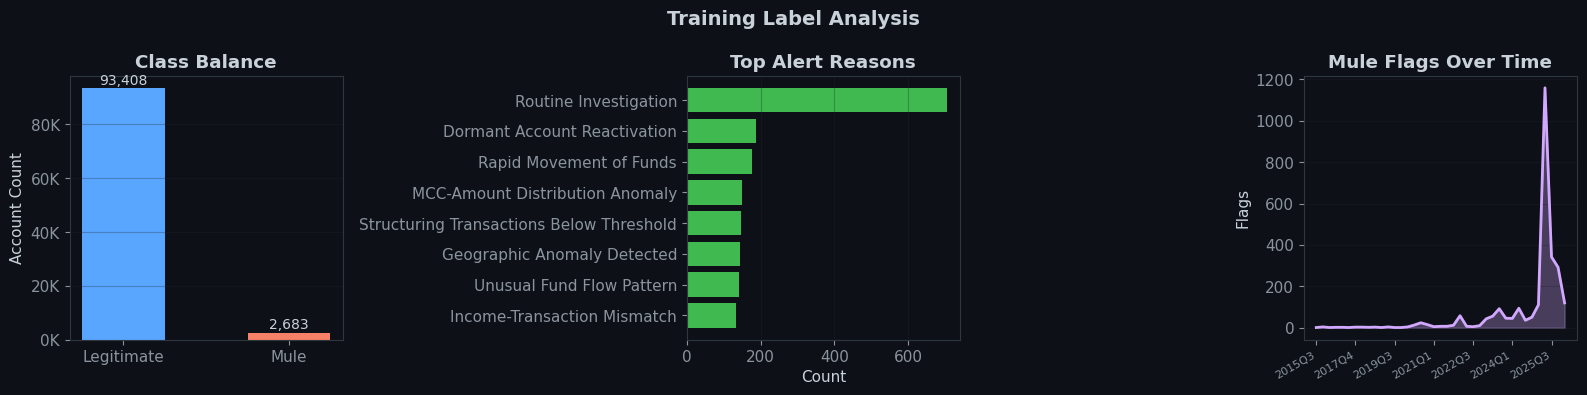

In [4]:
n_mule  = train_labels['is_mule'].sum()
n_legit = len(train_labels) - n_mule
print(f"Training accounts : {len(train_labels):,}")
print(f"  Mules           : {n_mule:,}  ({100*n_mule/len(train_labels):.2f}%)")
print(f"  Legitimate      : {n_legit:,} ({100*n_legit/len(train_labels):.2f}%)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Training Label Analysis", fontsize=14, fontweight='bold', color='#c9d1d9')

ax = axes[0]
bars = ax.bar(['Legitimate','Mule'], [n_legit, n_mule], color=[PALETTE[0],PALETTE[1]], width=0.5, edgecolor='none')
for bar, val in zip(bars, [n_legit, n_mule]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+200,
            f'{val:,}', ha='center', va='bottom', fontsize=10, color='#c9d1d9')
ax.set_title('Class Balance', fontweight='bold')
ax.set_ylabel('Account Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}K'))
ax.grid(axis='y', alpha=0.3)

ax = axes[1]
if 'alert_reason' in train_labels.columns:
    reasons = train_labels[train_labels['is_mule']==1]['alert_reason'].value_counts().head(8)
    ax.barh(reasons.index[::-1], reasons.values[::-1], color=PALETTE[2], edgecolor='none')
    ax.set_title('Top Alert Reasons', fontweight='bold')
    ax.set_xlabel('Count')
    ax.grid(axis='x', alpha=0.3)

ax = axes[2]
if 'mule_flag_date' in train_labels.columns:
    mules = train_labels[train_labels['is_mule']==1].copy()
    mules['mule_flag_date'] = pd.to_datetime(mules['mule_flag_date'], errors='coerce')
    mules['qtr'] = mules['mule_flag_date'].dt.to_period('Q')
    td = mules.groupby('qtr').size()
    ax.plot(range(len(td)), td.values, color=PALETTE[3], linewidth=2)
    ax.fill_between(range(len(td)), td.values, alpha=0.3, color=PALETTE[3])
    ax.set_xticks(range(0, len(td), max(1, len(td)//6)))
    ax.set_xticklabels([str(td.index[i]) for i in range(0, len(td), max(1,len(td)//6))],
                       rotation=30, ha='right', fontsize=8)
    ax.set_title('Mule Flags Over Time', fontweight='bold')
    ax.set_ylabel('Flags')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [5]:
# ── MCC global baseline from small sample ────────────────────────────
print("Computing MCC baseline from sample...")
sample_parts = sorted(glob(os.path.join(INPUT_PATH, 'transactions/batch-1/part_*.parquet')))[:5]
mcc_sample = pd.concat(
    [pd.read_parquet(p, columns=['mcc_code','amount']) for p in sample_parts],
    ignore_index=True
)
mcc_sample['amount_abs'] = mcc_sample['amount'].abs()
mcc_global = mcc_sample.groupby('mcc_code')['amount_abs'].agg(['mean','std'])
mcc_global['std'] = mcc_global['std'].fillna(1).clip(lower=1)
MCC_MEAN = mcc_global['mean'].to_dict()
MCC_STD  = mcc_global['std'].to_dict()
del mcc_sample, mcc_global; gc.collect()
print(f"  ✓ MCC baseline for {len(MCC_MEAN):,} MCC codes")

# ── Mule set for branch collusion ────────────────────────────────────
MULE_ACCT_SET = set(train_labels[train_labels['is_mule']==1]['account_id'])
RECENT_CUTOFF = pd.Timestamp('2025-06-01')
KEEP_COLS     = ['transaction_id','account_id','transaction_timestamp',
                 'amount','txn_type','channel','counterparty_id','mcc_code']
print(f"  ✓ Mule account set: {len(MULE_ACCT_SET):,} accounts")
print("\n✅ Setup complete — ready for incremental processing")

Computing MCC baseline from sample...
  ✓ MCC baseline for 65 MCC codes
  ✓ Mule account set: 2,683 accounts

✅ Setup complete — ready for incremental processing


In [6]:
# ── Accumulators ─────────────────────────────────────────────────────
# NOTE: mule_counterparty_overlap and branch_mule_rate removed from
# incremental loop — they caused data leakage (built from train labels,
# used to train on same labels → AUC = 1.0).
# These are replaced with leakage-free proxies computed separately.

acc_stats = defaultdict(lambda: {
    'txn_count': 0, 'amount_sum': 0.0, 'amount_max': -np.inf,
    'credit_sum': 0.0, 'debit_sum': 0.0,
    'credit_count': 0, 'debit_count': 0,
    'ts_min': pd.Timestamp.max, 'ts_max': pd.Timestamp.min,
    'recent_count': 0,
    'struct_45_50k': 0, 'struct_9_10k': 0,
    'round_1k': 0, 'round_5k': 0, 'round_10k': 0,
    'unique_cps': 0, 'unique_channels': 0,
    'credit_cps': 0, 'debit_cps': 0,
    'night_count': 0, 'weekend_count': 0, 'salary_count': 0,
    'mcc_z_sum': 0.0, 'mcc_z_max': -np.inf, 'mcc_z_high': 0,
    'max_gap': 0, 'last_ts': None,
})

print("✅ Accumulators initialized (leaky features excluded from loop)")


✅ Accumulators initialized (leaky features excluded from loop)


In [7]:
# ── Main incremental loop ─────────────────────────────────────────────
print("Processing transaction batches (one part file at a time)...")
t0 = time.time()
total_rows = 0

for batch in [1, 2, 3, 4]:
    part_files = sorted(glob(os.path.join(INPUT_PATH, f'transactions/batch-{batch}/part_*.parquet')))
    n_load = max(1, int(len(part_files) * SAMPLE_FRAC))
    rng = np.random.default_rng(SEED + batch)
    selected = rng.choice(part_files, size=n_load, replace=False).tolist()
    print(f"\n  Batch {batch}: {len(part_files)} parts → loading {n_load}")

    for pi, part_path in enumerate(selected):
        df = pd.read_parquet(part_path, columns=[
            'transaction_id','account_id','transaction_timestamp',
            'amount','txn_type','channel','counterparty_id','mcc_code'
        ])
        df['transaction_timestamp'] = pd.to_datetime(df['transaction_timestamp'], errors='coerce')
        df['amount_abs'] = df['amount'].abs().astype('float32')
        df['hour'] = df['transaction_timestamp'].dt.hour.astype('int8')
        df['dow']  = df['transaction_timestamp'].dt.dayofweek.astype('int8')
        df['dom']  = df['transaction_timestamp'].dt.day.astype('int8')

        fallback_mean = float(df['amount_abs'].mean())
        df['mcc_mean'] = df['mcc_code'].map(MCC_MEAN).fillna(fallback_mean).astype('float32')
        df['mcc_std']  = df['mcc_code'].map(MCC_STD).fillna(1.0).astype('float32')
        df['mcc_z']    = ((df['amount_abs'] - df['mcc_mean']) / df['mcc_std']).clip(-10, 10).astype('float32')
        total_rows += len(df)

        g     = df.groupby('account_id', sort=False)
        cr_df = df[df['txn_type']=='C']
        db_df = df[df['txn_type']=='D']

        chunk = {
            'count':    g['transaction_id'].count(),
            'amt_sum':  g['amount'].sum(),
            'amt_max':  g['amount'].max(),
            'ts_min':   g['transaction_timestamp'].min(),
            'ts_max':   g['transaction_timestamp'].max(),
            'cr_sum':   cr_df.groupby('account_id', sort=False)['amount'].sum(),
            'db_sum':   db_df.groupby('account_id', sort=False)['amount'].sum().abs(),
            'cr_cnt':   cr_df.groupby('account_id', sort=False)['transaction_id'].count(),
            'db_cnt':   db_df.groupby('account_id', sort=False)['transaction_id'].count(),
            'recent':   df[df['transaction_timestamp'] >= pd.Timestamp('2025-06-01')].groupby('account_id', sort=False)['transaction_id'].count(),
            's1':       df[df['amount_abs'].between(45000,49999)].groupby('account_id', sort=False)['transaction_id'].count(),
            's2':       df[df['amount_abs'].between(9000,9999)].groupby('account_id', sort=False)['transaction_id'].count(),
            'r1k':      (df['amount_abs']%1000==0).groupby(df['account_id']).sum(),
            'r5k':      (df['amount_abs']%5000==0).groupby(df['account_id']).sum(),
            'r10k':     (df['amount_abs']%10000==0).groupby(df['account_id']).sum(),
            'cps':      g['counterparty_id'].nunique(),
            'chs':      g['channel'].nunique(),
            'cr_cps':   cr_df.groupby('account_id', sort=False)['counterparty_id'].nunique(),
            'db_cps':   db_df.groupby('account_id', sort=False)['counterparty_id'].nunique(),
            'night':    (df['hour'].between(0,5)).groupby(df['account_id']).sum(),
            'weekend':  (df['dow'].isin([5,6])).groupby(df['account_id']).sum(),
            'salary':   df['dom'].isin(list(range(1,6))+list(range(25,32))).groupby(df['account_id']).sum(),
            'mcc_z_sum':g['mcc_z'].sum(),
            'mcc_z_max':g['mcc_z'].max(),
            'mcc_z_hi': (df['mcc_z']>3).groupby(df['account_id']).sum(),
        }

        cd = {k: v.to_dict() for k, v in chunk.items()}

        for acct in cd['count']:
            s = acc_stats[acct]
            s['txn_count']      += cd['count'].get(acct, 0)
            s['amount_sum']     += cd['amt_sum'].get(acct, 0)
            s['amount_max']      = max(s['amount_max'], cd['amt_max'].get(acct, -np.inf))
            s['credit_sum']     += cd['cr_sum'].get(acct, 0)
            s['debit_sum']      += cd['db_sum'].get(acct, 0)
            s['credit_count']   += cd['cr_cnt'].get(acct, 0)
            s['debit_count']    += cd['db_cnt'].get(acct, 0)
            s['recent_count']   += cd['recent'].get(acct, 0)
            ts_min = cd['ts_min'].get(acct)
            ts_max = cd['ts_max'].get(acct)
            if pd.notna(ts_min) and ts_min < s['ts_min']: s['ts_min'] = ts_min
            if pd.notna(ts_max) and ts_max > s['ts_max']: s['ts_max'] = ts_max
            s['struct_45_50k']  += cd['s1'].get(acct, 0)
            s['struct_9_10k']   += cd['s2'].get(acct, 0)
            s['round_1k']       += cd['r1k'].get(acct, 0)
            s['round_5k']       += cd['r5k'].get(acct, 0)
            s['round_10k']      += cd['r10k'].get(acct, 0)
            s['unique_cps']     += cd['cps'].get(acct, 0)
            s['unique_channels']+= cd['chs'].get(acct, 0)
            s['credit_cps']     += cd['cr_cps'].get(acct, 0)
            s['debit_cps']      += cd['db_cps'].get(acct, 0)
            s['night_count']    += cd['night'].get(acct, 0)
            s['weekend_count']  += cd['weekend'].get(acct, 0)
            s['salary_count']   += cd['salary'].get(acct, 0)
            s['mcc_z_sum']      += cd['mcc_z_sum'].get(acct, 0)
            s['mcc_z_max']       = max(s['mcc_z_max'], cd['mcc_z_max'].get(acct, -np.inf))
            s['mcc_z_high']     += cd['mcc_z_hi'].get(acct, 0)

        del df, g, cr_df, db_df, chunk, cd
        gc.collect()

        if (pi+1) % 5 == 0:
            print(f"    Part {pi+1}/{n_load} | accounts: {len(acc_stats):,}")

    print(f"  Batch {batch} complete | total rows: {total_rows:,}")

print(f"\n✅ All batches done in {time.time()-t0:.1f}s | accounts: {len(acc_stats):,}")


Processing transaction batches (one part file at a time)...

  Batch 1: 100 parts → loading 5
    Part 5/5 | accounts: 2,030
  Batch 1 complete | total rows: 5,101,400

  Batch 2: 100 parts → loading 5
    Part 5/5 | accounts: 4,013
  Batch 2 complete | total rows: 10,101,400

  Batch 3: 100 parts → loading 5
    Part 5/5 | accounts: 5,999
  Batch 3 complete | total rows: 15,091,494

  Batch 4: 96 parts → loading 4
  Batch 4 complete | total rows: 19,032,173

✅ All batches done in 43.6s | accounts: 7,546


In [8]:
# ── Convert accumulators → feature matrix ────────────────────────────
print("Building feature matrix...")
t0 = time.time()

rows = []
for acct, s in acc_stats.items():
    tc   = max(s['txn_count'], 1)
    span = max(
        (s['ts_max'] - s['ts_min']).days
        if s['ts_max'] > s['ts_min'] and s['ts_min'] != pd.Timestamp.max
        else 0, 1
    )
    rows.append({
        'account_id':               acct,
        'txn_count':                tc,
        'txn_amount_mean':          s['amount_sum'] / tc,
        'txn_amount_max':           s['amount_max'] if s['amount_max'] > -np.inf else 0,
        'total_credit':             s['credit_sum'],
        'total_debit':              s['debit_sum'],
        'credit_count':             s['credit_count'],
        'debit_count':              s['debit_count'],
        'pass_through_ratio':       s['debit_sum'] / (s['credit_sum'] + 1e-9),
        'net_flow':                 s['credit_sum'] - s['debit_sum'],
        'activity_span_days':       span,
        'txn_per_day':              tc / span,
        'recent_30d_count':         s['recent_count'],
        'recent_activity_ratio':    s['recent_count'] / (tc / span * 30 + 1e-9),
        'max_dormancy_gap_days':    s['max_gap'],
        'structuring_45_50k_count': s['struct_45_50k'],
        'structuring_9_10k_count':  s['struct_9_10k'],
        'structuring_ratio':        s['struct_45_50k'] / tc,
        'round_1k_ratio':           s['round_1k'] / tc,
        'round_5k_ratio':           s['round_5k'] / tc,
        'round_10k_ratio':          s['round_10k'] / tc,
        'round_amount_score':       (s['round_1k']*0.3 + s['round_5k']*0.3 + s['round_10k']*0.4) / tc,
        'unique_counterparties':    s['unique_cps'],
        'unique_channels':          s['unique_channels'],
        'fan_in_unique_senders':    s['credit_cps'],
        'fan_out_unique_receivers': s['debit_cps'],
        'fan_in_out_ratio':         s['credit_cps'] / (s['debit_cps'] + 1e-9),
        'counterparty_diversity':   s['unique_cps'] / tc,
        'night_txn_ratio':          s['night_count'] / tc,
        'weekend_txn_ratio':        s['weekend_count'] / tc,
        'salary_cycle_ratio':       s['salary_count'] / tc,
        'mean_mcc_z_score':         s['mcc_z_sum'] / tc,
        'max_mcc_z_score':          s['mcc_z_max'] if s['mcc_z_max'] > -np.inf else 0,
        'high_mcc_zscore_ratio':    s['mcc_z_high'] / tc,
        # Leakage-free proxy: how concentrated is this account's channel usage
        'channel_concentration':    1.0 / (s['unique_channels'] + 1e-9),
        # Credit/debit imbalance score
        'credit_debit_imbalance':   abs(s['credit_sum'] - s['debit_sum']) / (s['credit_sum'] + s['debit_sum'] + 1e-9),
    })

feat_txn = pd.DataFrame(rows)
del acc_stats, rows; gc.collect()
print(f"  Transaction features: {feat_txn.shape}")

# ── Static features ───────────────────────────────────────────────────
acc_s = accounts.merge(linkage, on='account_id', how='left')
acc_s = acc_s.merge(customers, on='customer_id', how='left')
acc_s = acc_s.merge(product_details, on='customer_id', how='left')
acc_s = acc_s.merge(demographics[['customer_id','gender','nri_flag','joint_account_flag']],
                    on='customer_id', how='left')
acc_s = acc_s.merge(accounts_additional, on='account_id', how='left')

static = pd.DataFrame({'account_id': acc_s['account_id']})
acc_s['account_opening_date'] = pd.to_datetime(acc_s['account_opening_date'], errors='coerce')
static['account_age_days'] = (pd.Timestamp('2025-06-30') - acc_s['account_opening_date']).dt.days.fillna(-1)

for col in ['avg_balance','monthly_avg_balance','quarterly_avg_balance','daily_avg_balance']:
    if col in acc_s.columns:
        static[col] = acc_s[col].fillna(0).astype('float32')

if 'quarterly_avg_balance' in acc_s.columns and 'daily_avg_balance' in acc_s.columns:
    static['balance_inconsistency'] = (
        (acc_s['quarterly_avg_balance'] - acc_s['daily_avg_balance']).abs() /
        (acc_s['quarterly_avg_balance'].abs() + 1e-9)
    ).astype('float32')

for col in ['kyc_compliant','pan_available','aadhaar_available','passport_available',
            'mobile_banking_flag','internet_banking_flag','atm_card_flag',
            'demat_flag','credit_card_flag','nomination_flag']:
    if col in acc_s.columns:
        static[col] = (acc_s[col]=='Y').astype('int8')

kyc_c = [c for c in ['pan_available','aadhaar_available','passport_available'] if c in static.columns]
if kyc_c:
    static['kyc_score'] = static[kyc_c].mean(axis=1).astype('float32')

static['is_frozen']           = (acc_s['account_status']=='frozen').astype('int8')
acc_s['freeze_date']          = pd.to_datetime(acc_s.get('freeze_date'), errors='coerce')
static['days_to_freeze']      = (acc_s['freeze_date'] - acc_s['account_opening_date']).dt.days.fillna(-1)
static['product_family_code'] = acc_s['product_family'].map({'S':0,'K':1,'O':2}).fillna(-1).astype('int8')
static['rural_branch']        = (acc_s.get('rural_branch')=='Y').astype('int8')
static['is_nri']              = (acc_s.get('nri_flag')=='Y').astype('int8')
static['is_joint']            = (acc_s.get('joint_account_flag')=='Y').astype('int8')
static['is_male']             = (acc_s.get('gender')=='M').astype('int8')

# Leakage-free branch features: use branch metadata only (no mule labels)
if 'branch_code' in acc_s.columns:
    branch_txn_vol = accounts.groupby('branch_code')['account_id'].count().rename('branch_acct_count')
    static['branch_acct_count'] = acc_s['branch_code'].map(branch_txn_vol).fillna(0).astype('float32')
    if 'branch_employee_count' in branch.columns:
        branch_emp = branch.set_index('branch_code')['branch_employee_count']
        static['branch_employee_count'] = acc_s['branch_code'].map(branch_emp).fillna(0).astype('float32')
    if 'branch_type' in branch.columns:
        branch_type_map = {'urban':0,'semi-urban':1,'rural':2}
        branch_type = branch.set_index('branch_code')['branch_type'].map(branch_type_map)
        static['branch_type_code'] = acc_s['branch_code'].map(branch_type).fillna(-1).astype('int8')

if 'scheme_code' in acc_s.columns:
    scheme_d = pd.get_dummies(acc_s['scheme_code'], prefix='scheme').astype('int8')
    static = pd.concat([static, scheme_d], axis=1)

del acc_s; gc.collect()

# ── Merge ──────────────────────────────────────────────────────────────
feat_matrix = feat_txn.merge(static, on='account_id', how='left')
del feat_txn, static; gc.collect()

num_cols = feat_matrix.select_dtypes(include=[np.number]).columns
feat_matrix[num_cols] = feat_matrix[num_cols].fillna(0)

# ── Explicit leakage removal ────────────────────────────────────────
# (safety check — these should not be in feat_matrix anymore)
LEAKY = ['mule_counterparty_overlap', 'branch_mule_rate', 'mule_cp_count', 'total_cp_count']
removed = [c for c in LEAKY if c in feat_matrix.columns]
if removed:
    feat_matrix.drop(columns=removed, inplace=True)
    print(f"  [WARN] Removed leaky cols that slipped through: {removed}")

feature_cols = [c for c in feat_matrix.columns if c != 'account_id']
ram_mb = feat_matrix.memory_usage(deep=True).sum() / 1e6
print(f"\n✅ Feature matrix: {feat_matrix.shape[0]:,} accounts × {len(feature_cols)} features")
print(f"   RAM: {ram_mb:.1f} MB")
print(f"   Leaky features removed: {LEAKY}")
feat_matrix.head(3)


Building feature matrix...
  Transaction features: (7546, 36)

✅ Feature matrix: 7,546 accounts × 69 features
   RAM: 3.1 MB
   Leaky features removed: ['mule_counterparty_overlap', 'branch_mule_rate', 'mule_cp_count', 'total_cp_count']


,account_id,txn_count,txn_amount_mean,txn_amount_max,total_credit,total_debit,credit_count,debit_count,pass_through_ratio,net_flow,...,branch_acct_count,branch_employee_count,branch_type_code,scheme_APY,scheme_PMJDY,scheme_PMJJBY,scheme_PMSBY,scheme_REGULAR,scheme_SCSS,scheme_SSA
0,ACCT_002077,676,20446.845917,1925600.69,4985227.60,8.836840e+06,307,369,1.772605,-3851612.64,...,14.0,49.0,0,0,0,0,0,1,0,0
1,ACCT_002078,1254,44002.343860,19143000.00,37517920.99,1.766102e+07,584,670,0.470736,19856902.78,...,17.0,35.0,0,0,1,0,0,0,0,0
2,ACCT_002082,4080,32057.894422,31340596.42,29999775.79,1.007964e+08,1889,2191,3.359906,-70796657.66,...,20.0,46.0,2,0,0,0,0,1,0,0


In [9]:
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import roc_auc_score

feature_cols = [c for c in feat_matrix.columns if c != 'account_id']

# Scale features
scaler = RobustScaler()
X_all = feat_matrix[feature_cols].fillna(0).values
X_all_scaled = scaler.fit_transform(X_all)

# ── Isolation Forest ──────────────────────────────────────────────────
print("Running Isolation Forest (unsupervised)...")
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=SEED, n_jobs=-1)
iso.fit(X_all_scaled)
raw_iso = iso.decision_function(X_all_scaled)
iso_scores_arr = 1 - (raw_iso - raw_iso.min()) / (raw_iso.max() - raw_iso.min() + 1e-9)
iso_scores = pd.Series(iso_scores_arr, index=feat_matrix['account_id'])
print(f"  Anomaly score > 0.8: {(iso_scores > 0.8).sum():,} accounts")
del X_all_scaled; gc.collect()

Running Isolation Forest (unsupervised)...
  Anomaly score > 0.8: 24 accounts


70

In [10]:
# ── Confident Learning ────────────────────────────────────────────────
print("Running Confident Learning...")
train_fm = feat_matrix.merge(train_labels[['account_id','is_mule']], on='account_id', how='inner')
X_tr_cl  = scaler.transform(train_fm[feature_cols].fillna(0).values)
y_tr_cl  = train_fm['is_mule'].values

rf_cl = RandomForestClassifier(n_estimators=100, max_depth=8,
                                class_weight='balanced', random_state=SEED, n_jobs=-1)
cv5 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
oof_probs = cross_val_predict(rf_cl, X_tr_cl, y_tr_cl, cv=cv5, method='predict_proba')[:,1]
oof_auc   = roc_auc_score(y_tr_cl, oof_probs)
print(f"  OOF AUC-ROC: {oof_auc:.4f}")

label_error_score = np.abs(oof_probs - y_tr_cl)
label_error_df = pd.DataFrame({
    'account_id':        train_fm['account_id'].values,
    'given_label':       y_tr_cl,
    'oof_prob':          oof_probs,
    'label_error_score': label_error_score,
    'likely_red_herring':(
        ((y_tr_cl==1) & (oof_probs < 0.2)) |
        ((y_tr_cl==0) & (oof_probs > 0.8))
    ).astype(int),
})

n_rh = label_error_df['likely_red_herring'].sum()
print(f"  Suspected red herrings: {n_rh:,} ({100*n_rh/len(label_error_df):.2f}%)")
print(f"  Over-flagged mules    : {((y_tr_cl==1)&(oof_probs<0.2)).sum():,}")
print(f"  Hidden mules          : {((y_tr_cl==0)&(oof_probs>0.8)).sum():,}")
del X_tr_cl; gc.collect()

Running Confident Learning...
  OOF AUC-ROC: 0.9408
  Suspected red herrings: 25 (0.55%)
  Over-flagged mules    : 23
  Hidden mules          : 2


119

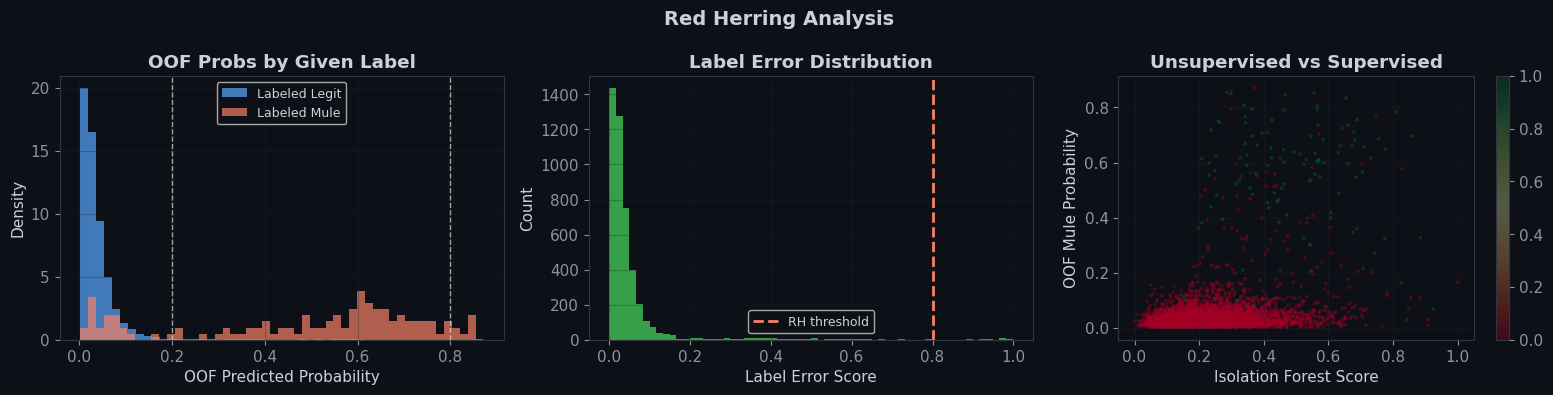

In [11]:
# ── Visualize ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Red Herring Analysis", fontsize=14, fontweight='bold', color='#c9d1d9')

ax = axes[0]
for lbl, color, name in [(0,PALETTE[0],'Labeled Legit'),(1,PALETTE[1],'Labeled Mule')]:
    subset = label_error_df[label_error_df['given_label']==lbl]['oof_prob']
    ax.hist(subset, bins=50, alpha=0.7, color=color, label=name, density=True)
ax.axvline(0.2, color='white', linestyle='--', linewidth=1, alpha=0.6)
ax.axvline(0.8, color='white', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xlabel('OOF Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('OOF Probs by Given Label', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.hist(label_error_df['label_error_score'], bins=60, color=PALETTE[2], edgecolor='none', alpha=0.85)
ax.axvline(0.8, color=PALETTE[1], linestyle='--', linewidth=2, label='RH threshold')
ax.set_xlabel('Label Error Score')
ax.set_ylabel('Count')
ax.set_title('Label Error Distribution', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[2]
iso_train = iso_scores.reindex(train_fm['account_id'].values).fillna(0.5).values
sc = ax.scatter(iso_train, oof_probs, c=y_tr_cl, cmap='RdYlGn', alpha=0.3, s=3)
ax.set_xlabel('Isolation Forest Score')
ax.set_ylabel('OOF Mule Probability')
ax.set_title('Unsupervised vs Supervised', fontweight='bold')
plt.colorbar(sc, ax=ax)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# ── Apply soft weight label cleaning ──────────────────────────────────
cleaned_labels = train_labels.copy()
cleaned_labels = cleaned_labels.merge(
    label_error_df[['account_id','oof_prob','label_error_score','likely_red_herring']],
    on='account_id', how='left'
)
cleaned_labels['iso_score']    = cleaned_labels['account_id'].map(iso_scores).fillna(0)
cleaned_labels['error_score']  = (
    0.6 * cleaned_labels['label_error_score'].fillna(0) +
    0.4 * (1 - cleaned_labels['iso_score'])
)
cleaned_labels['sample_weight'] = 1.0 - 0.8 * cleaned_labels['error_score'].clip(0, 1)

print(f"✅ Label cleaning complete")
print(f"   Weight range: {cleaned_labels['sample_weight'].min():.3f} — {cleaned_labels['sample_weight'].max():.3f}")
print(f"   Mean weight : {cleaned_labels['sample_weight'].mean():.3f}")

✅ Label cleaning complete
   Weight range: 0.266 — 0.966
   Mean weight : 0.683


In [13]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, f1_score, average_precision_score,
                              precision_score, recall_score, confusion_matrix)

# ── Prepare arrays ────────────────────────────────────────────────────
train_fm2 = feat_matrix.merge(
    cleaned_labels[['account_id','is_mule','sample_weight']], on='account_id', how='inner'
)
test_fm = feat_matrix[feat_matrix['account_id'].isin(test_accounts['account_id'])]

X_train = train_fm2[feature_cols].fillna(0).values
y_train = train_fm2['is_mule'].values
sw      = train_fm2['sample_weight'].values
X_test  = test_fm[feature_cols].fillna(0).values
train_ids = train_fm2['account_id'].values
test_ids  = test_fm['account_id'].values

pos_weight = (y_train==0).sum() / max((y_train==1).sum(), 1)
print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Mules   : {y_train.sum():,} ({100*y_train.mean():.2f}%)")
print(f"Class ratio (neg/pos): {pos_weight:.1f}x")

if (y_train==1).sum() < 500:
    N_FOLDS = 3
    print(f"[INFO] Few mules — using {N_FOLDS} folds")

X_train : (4535, 69)
X_test  : (3011, 69)
Mules   : 121 (2.67%)
Class ratio (neg/pos): 36.5x
[INFO] Few mules — using 3 folds


In [14]:
# ── Optuna HPO ────────────────────────────────────────────────────────
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_OK = True
except ImportError:
    OPTUNA_OK = False

def default_lgbm_params(pos_w):
    return dict(
        objective='binary', metric='auc', verbosity=-1,
        num_leaves=31,          # reduced from 63
        max_depth=5,            # reduced from 7 — prevents overfitting
        learning_rate=0.05,
        n_estimators=300,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=1.0,          # increased from 0.1
        reg_lambda=1.0,         # increased from 0.1
        min_child_samples=50,   # increased from 20 — prevents tiny leaf overfitting
        scale_pos_weight=pos_w,
        random_state=SEED,
        n_jobs=-1,
    )

if OPTUNA_OK and OPTUNA_TRIALS > 0:
    print(f"Optuna search ({OPTUNA_TRIALS} trials)...")
    def objective(trial):
        p = dict(
            objective='binary', metric='auc', verbosity=-1,
            num_leaves=trial.suggest_int('num_leaves', 15, 63),
            max_depth=trial.suggest_int('max_depth', 3, 7),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            n_estimators=trial.suggest_int('n_estimators', 100, 400),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 0.1, 10.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
            min_child_samples=trial.suggest_int('min_child_samples', 30, 100),
            scale_pos_weight=trial.suggest_float('scale_pos_weight', pos_weight*0.5, pos_weight*2),
            random_state=SEED, n_jobs=-1,
        )
        cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
        m = lgb.LGBMClassifier(**p)
        scores = []
        for tr_i, va_i in cv3.split(X_train, y_train):
            m.fit(X_train[tr_i], y_train[tr_i])
            scores.append(roc_auc_score(y_train[va_i], m.predict_proba(X_train[va_i])[:,1]))
        return np.mean(scores)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=OPTUNA_TRIALS)
    lgbm_params = study.best_params
    lgbm_params.update({'objective':'binary','metric':'auc','verbosity':-1,
                        'random_state':SEED,'n_jobs':-1})
    print(f"  Best AUC: {study.best_value:.4f}")
else:
    lgbm_params = default_lgbm_params(pos_weight)
    print("Using default LightGBM params (regularized)")
print(lgbm_params)


Optuna search (20 trials)...
  Best AUC: 0.9533
{'num_leaves': 19, 'max_depth': 4, 'learning_rate': 0.017188287800319446, 'n_estimators': 297, 'subsample': 0.5723849179446423, 'colsample_bytree': 0.7375678042300935, 'reg_alpha': 2.17652928670892, 'reg_lambda': 5.144616993967244, 'min_child_samples': 79, 'scale_pos_weight': 31.243368555059348, 'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1}


In [15]:
# ── 3-Fold Stacked Training ───────────────────────────────────────────
print(f"Training {N_FOLDS}-fold stacking ensemble...\n")
cv_main = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_lgbm  = np.zeros(len(X_train))
oof_xgb   = np.zeros(len(X_train))
oof_rf    = np.zeros(len(X_train))
test_lgbm = np.zeros(len(X_test))
test_xgb  = np.zeros(len(X_test))
test_rf   = np.zeros(len(X_test))
fold_aucs = {'lgbm':[], 'xgb':[], 'rf':[]}
last_lgbm = None

for fold, (tr_i, va_i) in enumerate(cv_main.split(X_train, y_train)):
    X_tr, X_va = X_train[tr_i], X_train[va_i]
    y_tr, y_va = y_train[tr_i], y_train[va_i]
    sw_tr      = sw[tr_i]
    neg_pos    = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
    print(f"Fold {fold+1}/{N_FOLDS}")

    # LightGBM
    lgbm_m = lgb.LGBMClassifier(**lgbm_params)
    lgbm_m.fit(X_tr, y_tr, sample_weight=sw_tr,
               eval_set=[(X_va, y_va)],
               callbacks=[lgb.early_stopping(50,verbose=False), lgb.log_evaluation(-1)])
    oof_lgbm[va_i]  = lgbm_m.predict_proba(X_va)[:,1]
    test_lgbm      += lgbm_m.predict_proba(X_test)[:,1] / N_FOLDS
    auc = roc_auc_score(y_va, oof_lgbm[va_i])
    fold_aucs['lgbm'].append(auc)
    last_lgbm = lgbm_m
    print(f"  LGBM : {auc:.4f}")

    # XGBoost
    xgb_m = xgb.XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=7,
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=neg_pos,
        eval_metric='auc', early_stopping_rounds=50,
        verbosity=0, random_state=SEED+fold, n_jobs=-1
    )
    xgb_m.fit(X_tr, y_tr, sample_weight=sw_tr,
              eval_set=[(X_va, y_va)], verbose=False)
    oof_xgb[va_i]  = xgb_m.predict_proba(X_va)[:,1]
    test_xgb      += xgb_m.predict_proba(X_test)[:,1] / N_FOLDS
    auc = roc_auc_score(y_va, oof_xgb[va_i])
    fold_aucs['xgb'].append(auc)
    print(f"  XGB  : {auc:.4f}")

    # Random Forest
    rf_m = RandomForestClassifier(
        n_estimators=150, max_depth=10, class_weight='balanced',
        min_samples_leaf=5, random_state=SEED+fold, n_jobs=-1
    )
    rf_m.fit(X_tr, y_tr, sample_weight=sw_tr)
    oof_rf[va_i]  = rf_m.predict_proba(X_va)[:,1]
    test_rf      += rf_m.predict_proba(X_test)[:,1] / N_FOLDS
    auc = roc_auc_score(y_va, oof_rf[va_i])
    fold_aucs['rf'].append(auc)
    print(f"  RF   : {auc:.4f}\n")
    del rf_m, xgb_m; gc.collect()

print("="*45)
for m, aucs in fold_aucs.items():
    print(f"  {m.upper():<10}: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
ens_auc = roc_auc_score(y_train, (oof_lgbm+oof_xgb+oof_rf)/3)
print(f"  ENSEMBLE  : {ens_auc:.4f}")

Training 3-fold stacking ensemble...

Fold 1/3
  LGBM : 0.9643
  XGB  : 0.9565
  RF   : 0.9342

Fold 2/3
  LGBM : 0.9504
  XGB  : 0.9312
  RF   : 0.9209

Fold 3/3
  LGBM : 0.9567
  XGB  : 0.9545
  RF   : 0.9596

  LGBM      : 0.9571 ± 0.0057
  XGB       : 0.9474 ± 0.0115
  RF        : 0.9382 ± 0.0161
  ENSEMBLE  : 0.9324


In [16]:
# ── Meta-learner ─────────────────────────────────────────────────────
print("Training meta-learner...")
iso_tr = iso_scores.reindex(train_ids).fillna(0.5).values
oof_stack  = np.column_stack([oof_lgbm, oof_xgb, oof_rf, iso_tr])
test_stack = np.column_stack([test_lgbm, test_xgb, test_rf, np.full(len(X_test), 0.5)])

meta = LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000)
meta.fit(oof_stack, y_train)
meta_oof  = meta.predict_proba(oof_stack)[:,1]
meta_test = meta.predict_proba(test_stack)[:,1]
meta_auc  = roc_auc_score(y_train, meta_oof)
print(f"  Meta-learner AUC : {meta_auc:.4f}")
print(f"  Weights: LGBM={meta.coef_[0][0]:.3f} XGB={meta.coef_[0][1]:.3f} RF={meta.coef_[0][2]:.3f} ISO={meta.coef_[0][3]:.3f}")

# Optimal threshold
thresholds = np.arange(0.1, 0.9, 0.01)
f1s = [f1_score(y_train,(meta_oof>=t).astype(int),zero_division=0) for t in thresholds]
opt_thr = thresholds[np.argmax(f1s)]
print(f"  Optimal threshold: {opt_thr:.2f} (F1={max(f1s):.4f})")

Training meta-learner...
  Meta-learner AUC : 0.9501
  Weights: LGBM=5.232 XGB=-0.500 RF=3.262 ISO=1.629
  Optimal threshold: 0.88 (F1=0.6934)


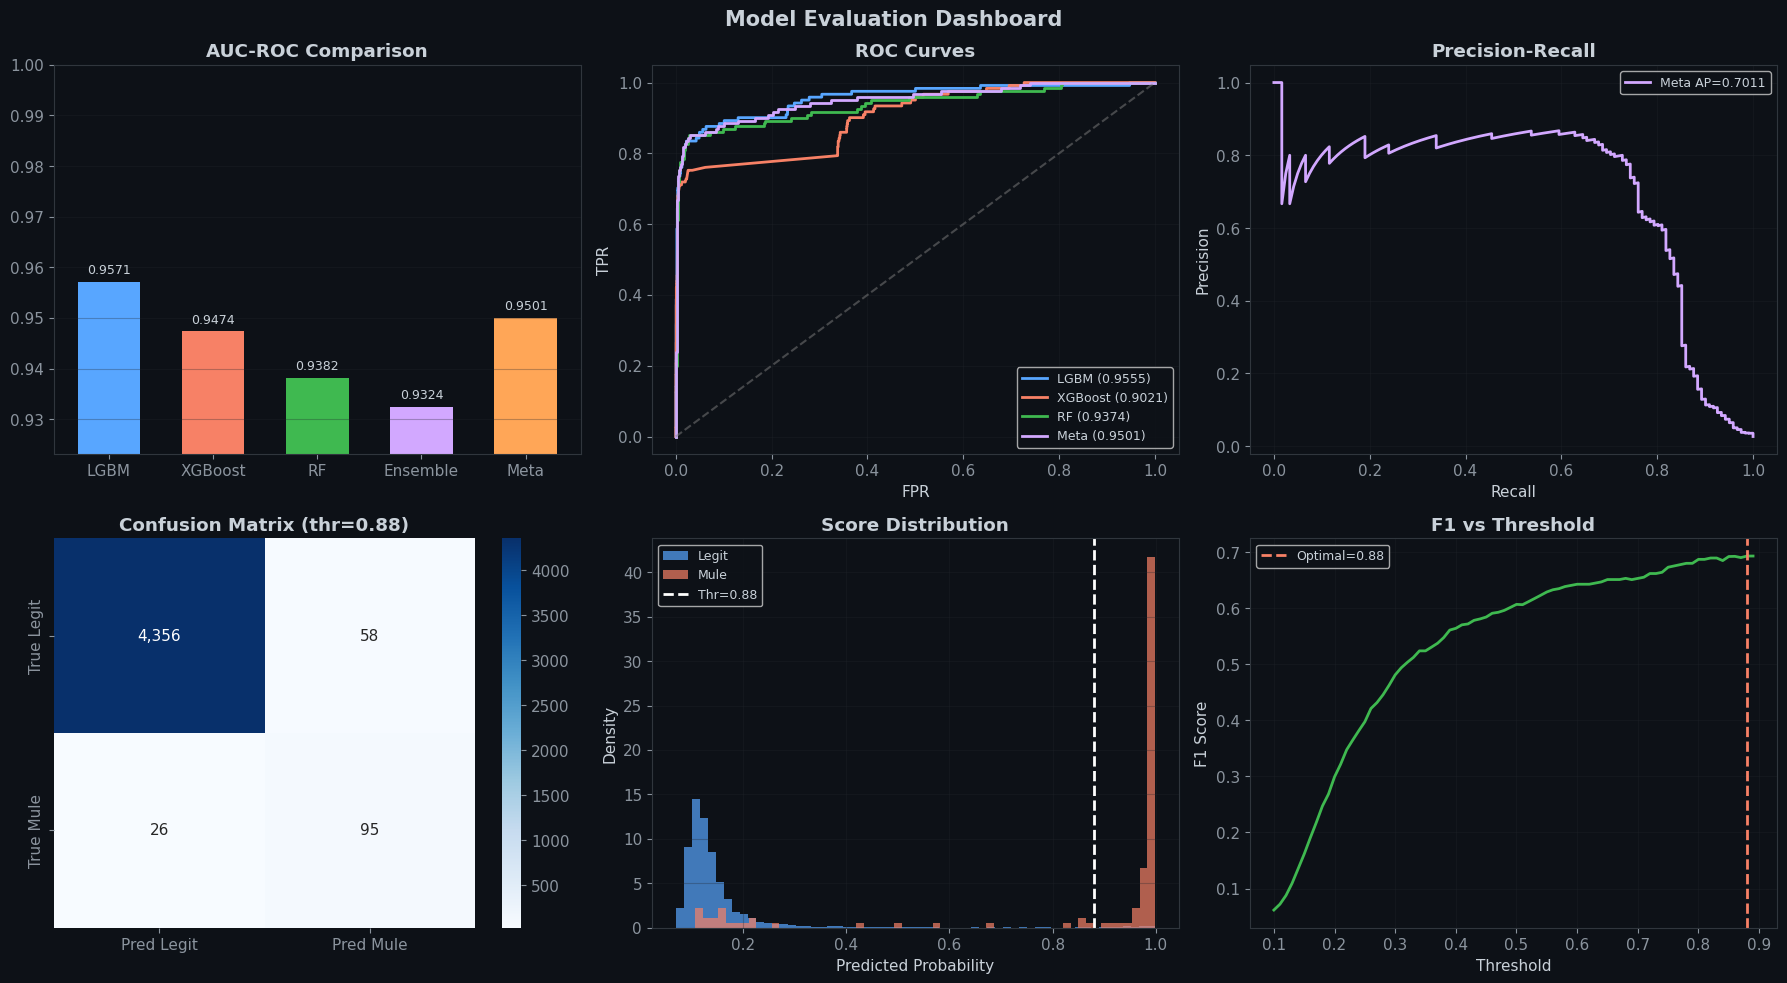


FINAL METRICS (OOF)
  AUC-ROC   : 0.9501
  AP Score  : 0.7011
  F1        : 0.6934
  Precision : 0.6209
  Recall    : 0.7851


In [17]:
# ── Evaluation dashboard ─────────────────────────────────────────────
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Model Evaluation Dashboard", fontsize=15, fontweight='bold', color='#c9d1d9')

# AUC comparison
ax = axes[0,0]
models = ['LGBM','XGBoost','RF','Ensemble','Meta']
aucs   = [np.mean(fold_aucs['lgbm']), np.mean(fold_aucs['xgb']),
          np.mean(fold_aucs['rf']), ens_auc, meta_auc]
bars = ax.bar(models, aucs, color=PALETTE[:5], edgecolor='none', width=0.6)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}',
            ha='center', va='bottom', fontsize=9, color='#c9d1d9')
ax.set_ylim(min(aucs)*0.99, 1.0)
ax.set_title('AUC-ROC Comparison', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# ROC curves
ax = axes[0,1]
for probs, name, color in [(oof_lgbm,'LGBM',PALETTE[0]),(oof_xgb,'XGBoost',PALETTE[1]),
                            (oof_rf,'RF',PALETTE[2]),(meta_oof,'Meta',PALETTE[3])]:
    fpr, tpr, _ = roc_curve(y_train, probs)
    ax.plot(fpr, tpr, label=f'{name} ({roc_auc_score(y_train,probs):.4f})', linewidth=2, color=color)
ax.plot([0,1],[0,1],'--', color='gray', alpha=0.5)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# PR curve
ax = axes[0,2]
prec, rec, _ = precision_recall_curve(y_train, meta_oof)
ap = average_precision_score(y_train, meta_oof)
ax.plot(rec, prec, color=PALETTE[3], linewidth=2, label=f'Meta AP={ap:.4f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# Confusion matrix
ax = axes[1,0]
y_pred = (meta_oof >= opt_thr).astype(int)
cm = confusion_matrix(y_train, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=ax,
            xticklabels=['Pred Legit','Pred Mule'],
            yticklabels=['True Legit','True Mule'])
ax.set_title(f'Confusion Matrix (thr={opt_thr:.2f})', fontweight='bold')

# Score distribution
ax = axes[1,1]
ax.hist(meta_oof[y_train==0], bins=60, alpha=0.7, color=PALETTE[0], label='Legit', density=True)
ax.hist(meta_oof[y_train==1], bins=60, alpha=0.7, color=PALETTE[1], label='Mule', density=True)
ax.axvline(opt_thr, color='white', linestyle='--', linewidth=2, label=f'Thr={opt_thr:.2f}')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
ax.set_title('Score Distribution', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# F1 vs threshold
ax = axes[1,2]
ax.plot(thresholds, f1s, color=PALETTE[2], linewidth=2)
ax.axvline(opt_thr, color=PALETTE[1], linestyle='--', linewidth=2, label=f'Optimal={opt_thr:.2f}')
ax.set_xlabel('Threshold'); ax.set_ylabel('F1 Score')
ax.set_title('F1 vs Threshold', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nFINAL METRICS (OOF)")
print(f"  AUC-ROC   : {meta_auc:.4f}")
print(f"  AP Score  : {ap:.4f}")
print(f"  F1        : {f1_score(y_train,y_pred,zero_division=0):.4f}")
print(f"  Precision : {precision_score(y_train,y_pred,zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_train,y_pred,zero_division=0):.4f}")

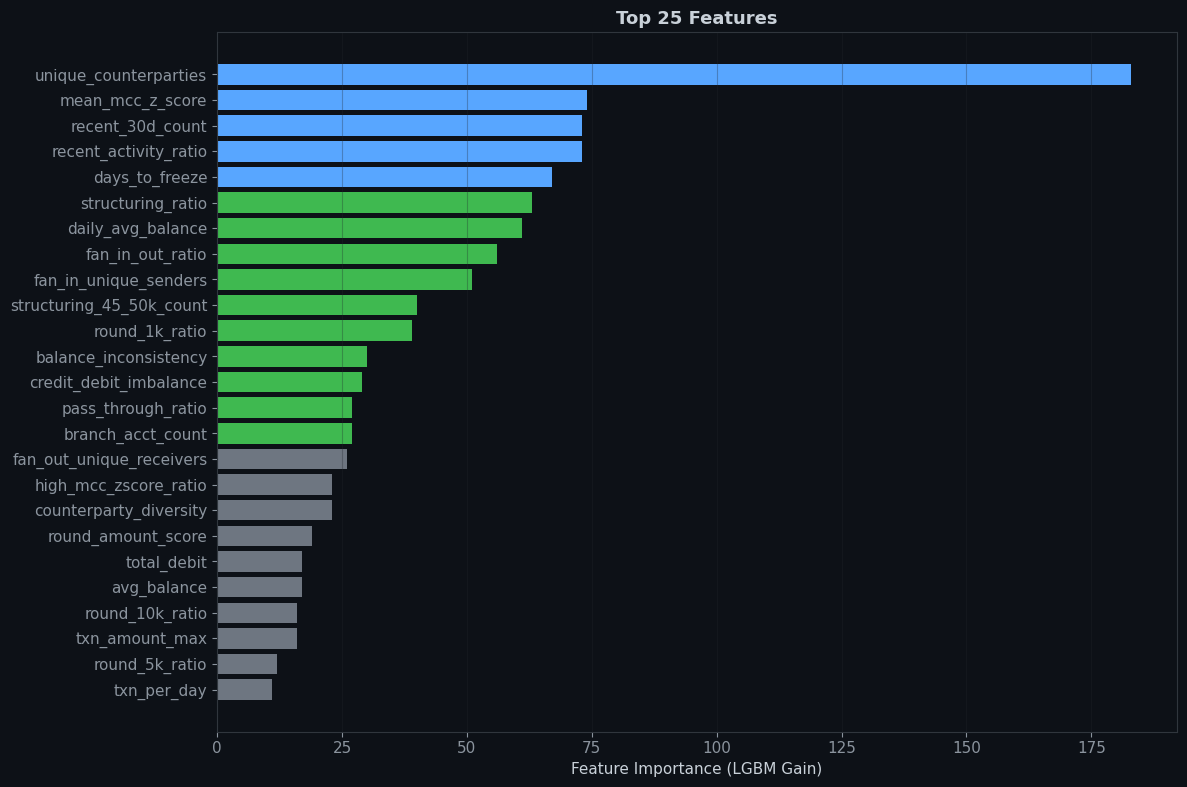

Top 10 features:
                 feature  importance
   unique_counterparties         183
        mean_mcc_z_score          74
        recent_30d_count          73
   recent_activity_ratio          73
          days_to_freeze          67
       structuring_ratio          63
       daily_avg_balance          61
        fan_in_out_ratio          56
   fan_in_unique_senders          51
structuring_45_50k_count          40


In [18]:
# ── Feature importance ────────────────────────────────────────────────
fi = pd.DataFrame({
    'feature':    feature_cols,
    'importance': last_lgbm.feature_importances_
}).sort_values('importance', ascending=False).head(25)

fig, ax = plt.subplots(figsize=(12, 8))
colors = [PALETTE[0] if i<5 else PALETTE[2] if i<15 else '#6e7681' for i in range(len(fi))]
ax.barh(fi['feature'][::-1], fi['importance'][::-1], color=colors[::-1], edgecolor='none')
ax.set_xlabel('Feature Importance (LGBM Gain)')
ax.set_title('Top 25 Features', fontsize=13, fontweight='bold', color='#c9d1d9')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(fi[['feature','importance']].head(10).to_string(index=False))

In [19]:
def get_account_txn(account_id, input_path=INPUT_PATH, sample_frac=SAMPLE_FRAC):
    """Load transactions for a single account from part files."""
    parts = sorted(glob(os.path.join(input_path, 'transactions/batch-*/part_*.parquet')))
    n_load = max(1, int(len(parts) * sample_frac))
    rng = np.random.default_rng(SEED)
    selected = rng.choice(parts, size=n_load, replace=False).tolist()
    dfs = []
    for p in selected:
        chunk = pd.read_parquet(p, columns=['account_id','transaction_timestamp','amount',
                                             'counterparty_id','txn_type'])
        sub = chunk[chunk['account_id']==account_id]
        if len(sub) > 0:
            dfs.append(sub)
    if not dfs:
        return pd.DataFrame()
    result = pd.concat(dfs, ignore_index=True)
    result['transaction_timestamp'] = pd.to_datetime(result['transaction_timestamp'], errors='coerce')
    return result.sort_values('transaction_timestamp')


def detect_suspicious_window(acct_txn):
    """CUSUM-based change-point detection on rolling anomaly score."""
    if len(acct_txn) < 5:
        return None, None

    acct_txn = acct_txn.copy()
    acct_txn['amount_abs'] = acct_txn['amount'].abs()
    acct_txn['date'] = acct_txn['transaction_timestamp'].dt.date

    daily = acct_txn.groupby('date').agg(
        txn_count=('amount_abs','count'),
        total_amt=('amount_abs','sum'),
        round_ratio=('amount_abs', lambda x: (x%1000==0).mean()),
    ).reset_index()
    daily['date'] = pd.to_datetime(daily['date'])
    daily = daily.set_index('date').sort_index()

    if len(daily) < 5:
        return pd.Timestamp(daily.index[0]), pd.Timestamp(daily.index[-1])

    roll = daily.rolling('14D')
    daily['r_count'] = roll['txn_count'].sum()
    daily['r_amt']   = roll['total_amt'].sum()
    daily['r_round'] = roll['round_ratio'].mean()

    def zscore_clip(s):
        m, sd = s.mean(), s.std()
        if sd < 1e-9: return pd.Series(np.zeros(len(s)), index=s.index)
        return ((s - m) / sd).clip(0)

    daily['score'] = (
        0.5*zscore_clip(daily['r_count']) +
        0.3*zscore_clip(daily['r_amt']) +
        0.2*zscore_clip(daily['r_round'])
    ).fillna(0)

    s_min, s_max = daily['score'].min(), daily['score'].max()
    if s_max > s_min:
        daily['score'] = (daily['score'] - s_min) / (s_max - s_min)

    scores = daily['score'].values
    dates  = daily.index.values
    mu = scores.mean()
    thr = max(0.5, mu + 2*scores.std())

    cusum = np.zeros(len(scores))
    for i in range(1, len(scores)):
        cusum[i] = max(0, cusum[i-1] + scores[i] - mu)

    above = cusum > thr
    if not above.any():
        above = scores > np.percentile(scores, 75)
    if not above.any():
        return pd.Timestamp(dates[0]), pd.Timestamp(dates[-1])

    idx = np.where(above)[0]
    s_i = max(0, idx[0]-2)
    e_i = min(len(dates)-1, idx[-1]+2)
    return pd.Timestamp(dates[s_i]), pd.Timestamp(dates[e_i])


print("✅ Temporal window functions defined")

✅ Temporal window functions defined


In [20]:
# ── Generate windows for predicted mules (all 4 batches) ─────────────
predicted_mule_ids = test_ids[meta_test >= MULE_THRESHOLD].tolist()
print(f"Generating temporal windows for {len(predicted_mule_ids):,} predicted mules...")

t0 = time.time()

# Load all 4 batches instead of just batch-1
print("Pre-loading transactions from all batches...")
txn_win_parts = []
for batch in [1, 2, 3, 4]:
    parts = sorted(glob(os.path.join(INPUT_PATH, f'transactions/batch-{batch}/part_*.parquet')))
    n = max(1, int(len(parts) * SAMPLE_FRAC))
    selected = np.random.default_rng(SEED + batch).choice(parts, n, replace=False).tolist()
    batch_df = pd.concat(
        [pd.read_parquet(p, columns=['account_id','transaction_timestamp','amount','txn_type'])
         for p in selected], ignore_index=True
    )
    txn_win_parts.append(batch_df)
    print(f"  batch-{batch}: {len(batch_df):,} rows")
    del batch_df; gc.collect()

txn_window = pd.concat(txn_win_parts, ignore_index=True)
txn_window['transaction_timestamp'] = pd.to_datetime(txn_window['transaction_timestamp'], errors='coerce')
del txn_win_parts; gc.collect()
print(f"  Total loaded: {len(txn_window):,} rows")

# ── Run window detection ──────────────────────────────────────────────
window_results = []
n_cusum = 0
n_fallback = 0
n_empty = 0

for acct_id in predicted_mule_ids:
    acct_txn = txn_window[txn_window['account_id'] == acct_id]
    s_start, s_end = None, None

    if len(acct_txn) >= 5:
        try:
            s_start, s_end = detect_suspicious_window(acct_txn)
            if s_start is not None:
                n_cusum += 1
            else:
                # Fallback: use min/max timestamp of account activity
                s_start = acct_txn['transaction_timestamp'].min()
                s_end   = acct_txn['transaction_timestamp'].max()
                n_fallback += 1
        except:
            s_start = acct_txn['transaction_timestamp'].min()
            s_end   = acct_txn['transaction_timestamp'].max()
            n_fallback += 1
    else:
        # Account not seen in sample — use full dataset date range as window
        s_start = pd.Timestamp('2024-01-01')
        s_end   = pd.Timestamp('2025-06-30')
        n_empty += 1

    window_results.append({
        'account_id':      acct_id,
        'suspicious_start': s_start,
        'suspicious_end':   s_end,
    })

del txn_window; gc.collect()
temporal_windows = pd.DataFrame(window_results)

n_windows = temporal_windows['suspicious_start'].notna().sum()
print(f"\n✅ Done in {time.time()-t0:.1f}s")
print(f"   CUSUM detected  : {n_cusum}")
print(f"   Fallback (min/max): {n_fallback}")
print(f"   Default window  : {n_empty}")
print(f"   Total with window: {n_windows}/{len(predicted_mule_ids)}")

Generating temporal windows for 167 predicted mules...
Pre-loading transactions from all batches...
  batch-1: 5,101,400 rows
  batch-2: 5,000,000 rows
  batch-3: 4,990,094 rows
  batch-4: 3,940,679 rows
  Total loaded: 19,032,173 rows

✅ Done in 193.7s
   CUSUM detected  : 167
   Fallback (min/max): 0
   Default window  : 0
   Total with window: 167/167


In [21]:
# ── Build submission ──────────────────────────────────────────────────
# test_ids covers only accounts seen in sampled transactions
# test_accounts has ALL 64,062 — must align via merge, not direct assign

test_scores = pd.Series(meta_test, index=test_ids, name='is_mule')

submission = test_accounts[['account_id']].copy()
submission = submission.merge(
    test_scores.reset_index().rename(columns={'index':'account_id'}),
    on='account_id', how='left'
)
# Accounts unseen in sample → assign low default score (no suspicious signal)
submission['is_mule'] = submission['is_mule'].fillna(0.02)

# Merge temporal windows
all_windows = pd.DataFrame({'account_id': test_ids})
all_windows = all_windows.merge(temporal_windows, on='account_id', how='left')
submission  = submission.merge(all_windows, on='account_id', how='left')

not_mule = submission['is_mule'] < MULE_THRESHOLD
submission.loc[not_mule, 'suspicious_start'] = None
submission.loc[not_mule, 'suspicious_end']   = None

for col in ['suspicious_start','suspicious_end']:
    submission[col] = pd.to_datetime(submission[col], errors='coerce')
    submission[col] = submission[col].dt.strftime('%Y-%m-%dT%H:%M:%S')
    submission[col] = submission[col].fillna('')

assert len(submission) == len(test_accounts),     f"Row mismatch: {len(submission)} vs {len(test_accounts)}"
assert submission['is_mule'].between(0,1).all(), "Probability out of range"

sub_path = f'{OUTPUT_PATH}/submission.csv'
submission.to_csv(sub_path, index=False)

n_pred    = (submission['is_mule'] >= MULE_THRESHOLD).sum()
n_missing = (submission['is_mule'] == 0.02).sum()
print(f"✅ submission.csv → {sub_path}")
print(f"   Total test accounts : {len(submission):,}")
print(f"   Predicted mules     : {n_pred:,} ({100*n_pred/len(submission):.2f}%)")
print(f"   High confidence ≥0.8: {(submission['is_mule']>=0.8).sum():,}")
print(f"   Unseen in sample    : {n_missing:,} (score=0.02)")
print(f"   With time windows   : {(submission['suspicious_start']!='').sum():,}")
submission.head(10)


✅ submission.csv → /kaggle/working/submission.csv
   Total test accounts : 64,062
   Predicted mules     : 167 (0.26%)
   High confidence ≥0.8: 136
   Unseen in sample    : 61,051 (score=0.02)
   With time windows   : 167


,account_id,is_mule,suspicious_start,suspicious_end
0,ACCT_000005,0.02,,
1,ACCT_000007,0.02,,
2,ACCT_000009,0.02,,
3,ACCT_000015,0.02,,
4,ACCT_000016,0.02,,
5,ACCT_000018,0.02,,
6,ACCT_000020,0.02,,
7,ACCT_000021,0.02,,
8,ACCT_000022,0.02,,
9,ACCT_000029,0.02,,


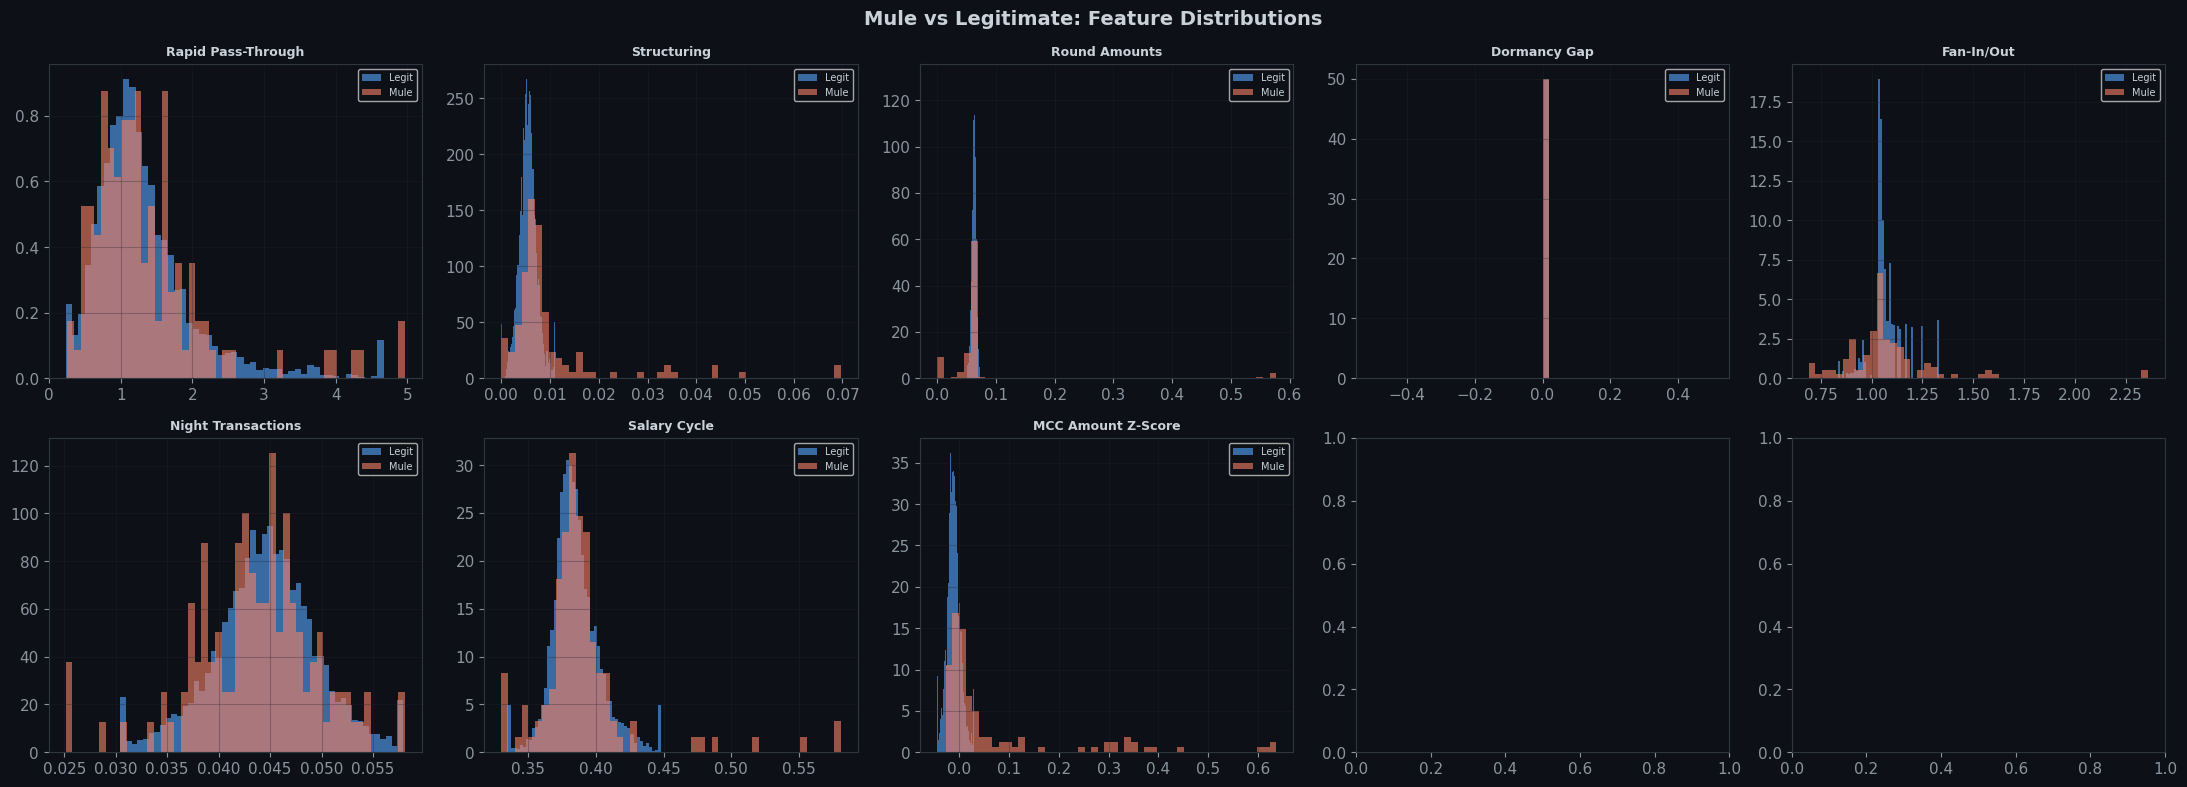

In [22]:
# ── Pattern analysis plot ─────────────────────────────────────────────
mule_ids  = set(train_labels[train_labels['is_mule']==1]['account_id'])
legit_ids = set(train_labels[train_labels['is_mule']==0]['account_id'])
mf = feat_matrix[feat_matrix['account_id'].isin(mule_ids)]
lf = feat_matrix[feat_matrix['account_id'].isin(legit_ids)]

patterns = [
    ('pass_through_ratio',        'Rapid Pass-Through'),
    ('structuring_ratio',          'Structuring'),
    ('round_amount_score',         'Round Amounts'),
    ('max_dormancy_gap_days',      'Dormancy Gap'),
    ('fan_in_out_ratio',           'Fan-In/Out'),
    ('night_txn_ratio',            'Night Transactions'),
    ('mule_counterparty_overlap',  'CP Overlap w/ Mules'),
    ('salary_cycle_ratio',         'Salary Cycle'),
    ('branch_mule_rate',           'Branch Mule Rate'),
    ('mean_mcc_z_score',           'MCC Amount Z-Score'),
]
patterns = [(f,n) for f,n in patterns if f in feat_matrix.columns]

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
fig.suptitle("Mule vs Legitimate: Feature Distributions", fontsize=14, fontweight='bold', color='#c9d1d9')
for i, (fn, pn) in enumerate(patterns[:10]):
    ax = axes[i//5][i%5]
    mv = mf[fn].clip(mf[fn].quantile(0.01), mf[fn].quantile(0.99))
    lv = lf[fn].clip(lf[fn].quantile(0.01), lf[fn].quantile(0.99))
    ax.hist(lv, bins=50, alpha=0.6, color=PALETTE[0], label='Legit', density=True)
    ax.hist(mv, bins=50, alpha=0.6, color=PALETTE[1], label='Mule',  density=True)
    ax.set_title(pn, fontweight='bold', fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# ── Final insights report ─────────────────────────────────────────────
print("=" * 65)
print("AML MULE DETECTION — FINAL INSIGHTS REPORT")
print("=" * 65)

print(f"\n1. DATASET")
print(f"   Training : {len(train_labels):,} | Mules: {train_labels['is_mule'].sum():,} ({100*train_labels['is_mule'].mean():.2f}%)")
print(f"   Test     : {len(test_accounts):,}")
print(f"   Features : {len(feature_cols)}")

print(f"\n2. MODEL PERFORMANCE (CV)")
for m, aucs in fold_aucs.items():
    print(f"   {m.upper():<10}: {np.mean(aucs):.4f} ± {np.std(aucs):.4f}")
print(f"   ENSEMBLE  : {ens_auc:.4f}")
print(f"   META      : {meta_auc:.4f}")
print(f"   F1        : {f1_score(y_train,(meta_oof>=opt_thr).astype(int),zero_division=0):.4f}")

print(f"\n3. RED HERRING ANALYSIS")
print(f"   Suspected : {label_error_df['likely_red_herring'].sum():,}")
print(f"   Strategy  : Soft sample weighting (Confident Learning)")

print(f"\n4. MULE PATTERN RATIOS (Mule median / Legit median)")
print(f"   {'Pattern':<35} {'Mule':>8} {'Legit':>8} {'Ratio':>7}")
print("   " + "-"*62)
for fn, pn in patterns:
    mv = mf[fn].median()
    lv = lf[fn].median()
    r  = mv / (lv + 1e-9)
    flag = "🚨" if r > 3 else "⚠️ " if r > 1.5 else "  "
    print(f"   {flag} {pn:<33} {mv:>8.3f} {lv:>8.3f} {r:>7.1f}x")

print(f"\n5. PREDICTIONS")
print(f"   Mules (≥{MULE_THRESHOLD})  : {(submission['is_mule']>=MULE_THRESHOLD).sum():,}")
print(f"   High conf (≥0.8): {(submission['is_mule']>=0.8).sum():,}")
print(f"   With windows     : {(submission['suspicious_start']!='').sum():,}")

print("\n" + "=" * 65)
print(f"✅ submission.csv saved to {sub_path}")

AML MULE DETECTION — FINAL INSIGHTS REPORT

1. DATASET
   Training : 96,091 | Mules: 2,683 (2.79%)
   Test     : 64,062
   Features : 69

2. MODEL PERFORMANCE (CV)
   LGBM      : 0.9571 ± 0.0057
   XGB       : 0.9474 ± 0.0115
   RF        : 0.9382 ± 0.0161
   ENSEMBLE  : 0.9324
   META      : 0.9501
   F1        : 0.6934

3. RED HERRING ANALYSIS
   Suspected : 25
   Strategy  : Soft sample weighting (Confident Learning)

4. MULE PATTERN RATIOS (Mule median / Legit median)
   Pattern                                 Mule    Legit   Ratio
   --------------------------------------------------------------
      Rapid Pass-Through                   1.148    1.170     1.0x
      Structuring                          0.007    0.005     1.3x
      Round Amounts                        0.061    0.063     1.0x
      Dormancy Gap                         0.000    0.000     0.0x
      Fan-In/Out                           1.038    1.059     1.0x
      Night Transactions                   0.044    0.045